# Color palette overview

Visualizes all colorblind-safe palettes included in the `cb_colors` package.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from cb_colors import palettes

matplotlib.rc_file("../../matplotlibrc_ml")
matplotlib.rcParams.update({"font.size": 7.5, "text.usetex": False})

In [2]:
def draw_swatches(ax, colors, label=None, show_hex=False):
    """Draw a row of color swatches on ax."""
    items = list(colors.items() if isinstance(colors, dict) else enumerate(colors))
    for i, (name, hex_color) in enumerate(items):
        rect = mpatches.FancyBboxPatch(
            (i, 0), 0.9, 0.8,
            boxstyle="round,pad=0.05",
            facecolor=hex_color, edgecolor="none"
        )
        ax.add_patch(rect)
        if isinstance(colors, dict) and show_hex:
            display_name = str(name).replace("_", "\n")
            ax.text(i + 0.45, -0.05, display_name, ha="center", va="top",
                    fontsize=5.5, color="#444", linespacing=1.1)
    n = len(items)
    ax.set_xlim(-0.1, n)
    ax.set_ylim(-0.55, 0.95)
    ax.axis("off")
    if label:
        ax.text(-0.015, 0.5, label, ha="right", va="center",
                fontsize=6.5, fontweight="bold", transform=ax.transAxes)

In [3]:
def draw_gradient(ax, colors, label=None):
    """Draw a gradient strip from a list of hex colors."""
    n = len(colors)
    for i, hex_color in enumerate(colors):
        rect = mpatches.FancyBboxPatch(
            (i, 0), 0.9, 0.8,
            boxstyle="round,pad=0.02",
            facecolor=hex_color, edgecolor="none"
        )
        ax.add_patch(rect)
    ax.set_xlim(-0.1, n)
    ax.set_ylim(-0.1, 0.95)
    ax.axis("off")
    if label:
        ax.text(-0.015, 0.5, label, ha="right", va="center",
                fontsize=6.5, fontweight="bold", transform=ax.transAxes)


def draw_pairs(ax, pairs):
    """Draw 2-color pairs side by side; gap between pairs, tight within each pair."""
    swatch_w  = 0.9
    inner_gap = 0.1    # tiny gap between the two colors in a pair
    pair_w    = 2 * swatch_w + inner_gap   # 1.9
    outer_gap = 0.55   # breathing room between different pairs
    slot_w    = pair_w + outer_gap         # 2.45

    for i, (name, (c1, c2)) in enumerate(pairs.items()):
        x0 = i * slot_w
        for j, color in enumerate([c1, c2]):
            rect = mpatches.FancyBboxPatch(
                (x0 + j * (swatch_w + inner_gap), 0), swatch_w, 0.8,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="none"
            )
            ax.add_patch(rect)
        x_mid = x0 + pair_w / 2
        ax.text(x_mid, -0.05, name.replace("_", "\n"), ha="center", va="top",
                fontsize=5.5, color="#444", linespacing=1.1)

    n = len(pairs)
    total_w = n * slot_w - outer_gap
    ax.set_xlim(-0.15, total_w + 0.15)
    ax.set_ylim(-0.55, 0.95)
    ax.axis("off")

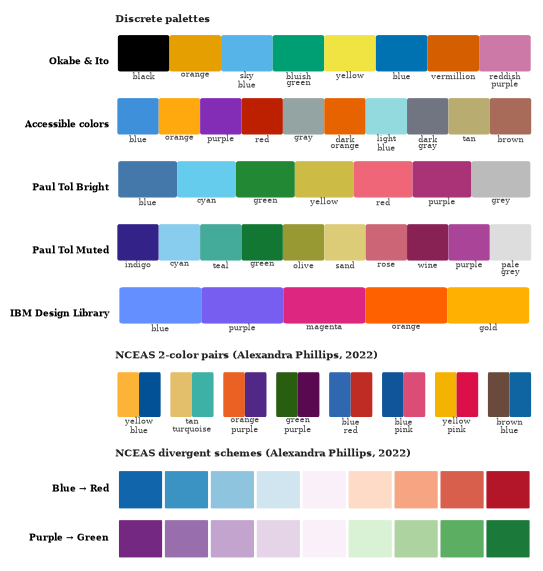

All palettes displayed


In [4]:
# ── Load all palettes ────────────────────────────────────────────────────────────────────────────────
oi     = palettes.okabe_and_ito()
ac     = palettes.accessible_colors()
ptb    = palettes.paul_tol_bright()
ptm    = palettes.paul_tol_muted()
ibm    = palettes.ibm_design_library()
pairs  = palettes.nceas_two_color_pairs()
btr    = palettes.nceas_blue_to_red()
ptg    = palettes.nceas_purple_to_green()

# ── Layout ────────────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=11, ncols=1,
    figsize=(5.5, 5.8),
    gridspec_kw={"height_ratios": [0.4, 1.3, 1.3, 1.3, 1.3, 1.3, 0.4, 1.6, 0.4, 1, 1]},
)
fig.subplots_adjust(hspace=0.05, left=0.22, right=0.98, top=0.97, bottom=0.02)

def section_header(ax, text):
    ax.text(0, 0.5, text, ha="left", va="center",
            fontsize=7, fontweight="bold", color="#222",
            transform=ax.transAxes)
    ax.axis("off")

section_header(axes[0], "Discrete palettes")
draw_swatches(axes[1],  oi,  label="Okabe & Ito",        show_hex=True)
draw_swatches(axes[2],  ac,  label="Accessible colors",  show_hex=True)
draw_swatches(axes[3],  ptb, label="Paul Tol Bright",    show_hex=True)
draw_swatches(axes[4],  ptm, label="Paul Tol Muted",     show_hex=True)
draw_swatches(axes[5],  ibm, label="IBM Design Library", show_hex=True)

section_header(axes[6], "NCEAS 2-color pairs (Alexandra Phillips, 2022)")
draw_pairs(axes[7], pairs)

section_header(axes[8], "NCEAS divergent schemes (Alexandra Phillips, 2022)")
draw_gradient(axes[9],  btr, label="Blue → Red")
draw_gradient(axes[10], ptg, label="Purple → Green")

plt.show()
print("All palettes displayed")

In [5]:
# ── Save ──────────────────────────────────────────────────────────────────────
out_path = "../png/color_overview.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved: {out_path}")

Saved: ../png/color_overview.png
